# Pipeline Validation Graphs — v2

Two fixes over the original:
- **IoU matching** — only scores detections that overlap (IoU ≥ 0.40) with a GT-annotated bee. Unlabelled background bees are excluded.
- **Majority-vote accuracy** — reports scene-level classification accuracy alongside per-detection accuracy.

Phase 1 + Phase 2 caches are reused. Only Phase 3 re-runs.

In [1]:
import os, glob, pickle, re
from pathlib import Path
from collections import defaultdict, deque
from datetime import datetime

import cv2
import numpy as np
import torch
import torch.nn as nn
from transformers import AutoModel
from torchvision import transforms
from ultralytics import YOLO
from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction
import supervision as sv
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from torch.amp.autocast_mode import autocast
from PIL import Image

%matplotlib inline
print(f'supervision: {sv.__version__}')
print('Imports OK')

supervision: 0.27.0.post1
Imports OK


In [2]:
BASE_DIR = 'D:/Projects/Masters'

TEMPORAL_PATH  = os.path.join(BASE_DIR, 'Trained_Models/ACT_best.pt')
ACTION_CLASSES = ['fanning', 'neutral', 'trophallaxis']
YOLO_PATH      = os.path.join(BASE_DIR, 'Trained_Models/DET_medium-best.pt')
AR_ROOT        = os.path.join(BASE_DIR, 'Data/AR_dataset')
DET_ROOT       = os.path.join(BASE_DIR, 'Data/DET_data_OG')
CACHE_DIR      = os.path.join(BASE_DIR, 'cache')
OUTPUT_DIR     = os.path.join(BASE_DIR, 'ActionRecognition/results/20260509_055348')

DET_CONF       = 0.45
SAHI_SLICE     = 640
SAHI_OVERLAP   = 0.35
CROP_PAD       = 0.35
TRACK_BUFFER   = 30
FPS            = 30
MIN_BUFFER     = 4
ACTION_CONF_TH = 0.55
IOU_THRESHOLD  = 0.15
DINO_BATCH     = 64

MAX_FRAMES_PER_DATASET = None

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(CACHE_DIR,  exist_ok=True)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Model          : {TEMPORAL_PATH}')
print(f'Output         : {OUTPUT_DIR}')
print(f'Device         : {device}')
print(f'Conf threshold : {ACTION_CONF_TH}')
print(f'IoU threshold  : {IOU_THRESHOLD}')

Model          : D:/Projects/Masters\Trained_Models/ACT_best.pt
Output         : D:/Projects/Masters\ActionRecognition/results/20260509_055348
Device         : cuda
Conf threshold : 0.55
IoU threshold  : 0.15


In [3]:
class TemporalSequenceClassifier(nn.Module):
    def __init__(self, feature_dim=768, num_classes=3, num_heads=6,
                 num_layers=3, dropout=0.35, max_seq_len=17):
        super().__init__()
        self.cls_token   = nn.Parameter(torch.randn(1, 1, feature_dim) * 0.02)
        self.pos_embed   = nn.Embedding(max_seq_len, feature_dim)
        encoder_layer    = nn.TransformerEncoderLayer(
            d_model=feature_dim, nhead=num_heads,
            dim_feedforward=feature_dim * 2,
            dropout=dropout, batch_first=True, norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm        = nn.LayerNorm(feature_dim)
        self.classifier  = nn.Sequential(
            nn.Linear(feature_dim, 256), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(256, num_classes),
        )

    def forward(self, x, padding_mask=None):
        B, T, _ = x.shape
        cls  = self.cls_token.expand(B, -1, -1)
        x    = torch.cat([cls, x], dim=1)
        pos  = torch.arange(T + 1, device=x.device).unsqueeze(0)
        x    = x + self.pos_embed(pos)
        if padding_mask is not None:
            cls_mask  = torch.zeros(B, 1, dtype=torch.bool, device=x.device)
            full_mask = torch.cat([cls_mask, padding_mask], dim=1)
        else:
            full_mask = None
        x = self.transformer(x, src_key_padding_mask=full_mask)
        return self.classifier(self.norm(x[:, 0]))

In [4]:
ckpt        = torch.load(TEMPORAL_PATH, map_location='cpu')
cfg         = ckpt['config']
BUFFER_SIZE = cfg['buffer_size']
temperature = float(ckpt.get('temperature', 1.0))

temporal_model = TemporalSequenceClassifier(
    feature_dim=cfg['feature_dim'], num_classes=cfg['num_classes'],
    num_heads=cfg['num_heads'],     num_layers=cfg['num_layers'],
    dropout=cfg['dropout'],         max_seq_len=BUFFER_SIZE + 1,
).to(device)
temporal_model.load_state_dict(ckpt['model_state'])
temporal_model.eval()

print(f"Epoch       : {ckpt['epoch']}  Val F1: {ckpt['val_f1']:.4f}")
print(f'Buffer      : {BUFFER_SIZE}  Temperature: {temperature:.4f}')
print(f'Classes     : {ACTION_CLASSES}')

Epoch       : 27  Val F1: 0.9638
Buffer      : 16  Temperature: 1.0000
Classes     : ['fanning', 'neutral', 'trophallaxis']


In [5]:
_preprocess = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

def extract_crop(frame, xyxy, pad=CROP_PAD):
    h, w = frame.shape[:2]
    x1, y1, x2, y2 = map(int, xyxy)
    px = int((x2-x1)*pad); py = int((y2-y1)*pad)
    x1 = max(0,x1-px); y1 = max(0,y1-py)
    x2 = min(w,x2+px); y2 = min(h,y2+py)
    crop = frame[y1:y2, x1:x2]
    return crop if crop.size > 0 else None

def classify_buffer_full(feature_list):
    T, N = BUFFER_SIZE, len(feature_list)
    feats, mask = [], []
    for i in range(T):
        if i < N:
            feats.append(feature_list[i]); mask.append(False)
        else:
            feats.append(feature_list[-1]); mask.append(True)
    x     = torch.stack(feats).unsqueeze(0).to(device)
    pmask = torch.tensor(mask, dtype=torch.bool).unsqueeze(0).to(device)
    with torch.no_grad(), autocast(str(device)):
        logits = temporal_model(x, padding_mask=pmask) / temperature
        probs  = torch.softmax(logits, dim=1)
    probs_np = probs.squeeze(0).cpu().numpy()
    conf, idx = probs.max(dim=1)
    label = ACTION_CLASSES[idx.item()] if conf.item() >= ACTION_CONF_TH else 'uncertain'
    return label, conf.item(), probs_np

print('Helpers ready')

Helpers ready


In [6]:
_img_dim_cache = {}

def get_image_dims(img_path):
    if img_path not in _img_dim_cache:
        with Image.open(img_path) as img:
            _img_dim_cache[img_path] = img.size  # (w, h)
    return _img_dim_cache[img_path]

def get_label_path(img_path):
    p     = Path(img_path)
    parts = p.parts
    try:
        idx = next(i for i, s in enumerate(parts) if s.lower() == 'ar_dataset')
        return str(Path(*parts[:idx+3]) / 'labels' / (p.stem + '.txt'))
    except StopIteration:
        return None

def load_gt_boxes(label_path, img_w, img_h):
    if label_path is None or not os.path.exists(label_path):
        return []
    boxes = []
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            _, cx, cy, bw, bh = map(float, parts[:5])
            x1 = max(0.0, (cx - bw/2)) * img_w
            y1 = max(0.0, (cy - bh/2)) * img_h
            x2 = min(1.0, (cx + bw/2)) * img_w
            y2 = min(1.0, (cy + bh/2)) * img_h
            boxes.append([x1, y1, x2, y2])
    return boxes

def compute_iou(a, b):
    xi1, yi1 = max(a[0],b[0]), max(a[1],b[1])
    xi2, yi2 = min(a[2],b[2]), min(a[3],b[3])
    inter = max(0.0, xi2-xi1) * max(0.0, yi2-yi1)
    ua = (a[2]-a[0])*(a[3]-a[1]); ub = (b[2]-b[0])*(b[3]-b[1])
    return inter / (ua + ub - inter) if (ua+ub-inter) > 0 else 0.0

def is_gt_matched(xyxy, gt_boxes):
    return any(compute_iou(list(xyxy), gt) >= IOU_THRESHOLD for gt in gt_boxes)

print('IoU helpers ready')

IoU helpers ready


In [7]:
def collect_images(folder):
    exts = ('.jpg', '.jpeg', '.png')
    return sorted(os.path.join(folder, f)
                  for f in os.listdir(folder) if f.lower().endswith(exts))

datasets = {}
for cls in ['fanning', 'trophallaxis']:
    paths = []
    for split in ['train', 'val']:
        folder = os.path.join(AR_ROOT, cls, split, 'images')
        if os.path.isdir(folder):
            paths.extend(collect_images(folder))
    datasets[cls] = sorted(paths)

det_folder = os.path.join(DET_ROOT, 'images')
if os.path.isdir(det_folder):
    datasets['det_data'] = collect_images(det_folder)

print('Dataset summary:')
for name, imgs in datasets.items():
    limit = f'  → using first {MAX_FRAMES_PER_DATASET}' if MAX_FRAMES_PER_DATASET else ''
    print(f'  {name:20s}: {len(imgs):,} images{limit}')

Dataset summary:
  fanning             : 18,000 images
  trophallaxis        : 20,480 images
  det_data            : 6,200 images


## Phase 1 — Detection + Tracking
Runs SAHI + ByteTrack. Saves `<dataset>_detections.pkl`. **Skips automatically if cache exists.**

In [8]:
yolo_model = YOLO(YOLO_PATH)
sahi_model = AutoDetectionModel.from_pretrained(
    model_type='ultralytics', model=yolo_model,
    confidence_threshold=DET_CONF, device=str(device),
)
print('YOLO + SAHI loaded')

for dataset_name, image_paths in datasets.items():
    cache_path = os.path.join(CACHE_DIR, f'{dataset_name}_detections.pkl')
    if os.path.exists(cache_path):
        print(f'  {dataset_name}: detection cache exists — skipping')
        continue

    paths_to_run = image_paths[:MAX_FRAMES_PER_DATASET] if MAX_FRAMES_PER_DATASET else image_paths
    print(f'\n{"="*60}\nDataset: {dataset_name}  ({len(paths_to_run):,} frames)')

    try:
        tracker = sv.ByteTrack(
            track_activation_threshold=0.45, lost_track_buffer=TRACK_BUFFER,
            minimum_matching_threshold=0.8,  frame_rate=FPS,
        )
    except TypeError:
        tracker = sv.ByteTrack()

    det_records = []
    for frame_idx, img_path in enumerate(paths_to_run):
        if frame_idx % 1000 == 0:
            print(f'  frame {frame_idx}/{len(paths_to_run)}', flush=True)
        result = get_sliced_prediction(
            img_path, sahi_model,
            slice_height=SAHI_SLICE, slice_width=SAHI_SLICE,
            overlap_height_ratio=SAHI_OVERLAP, overlap_width_ratio=SAHI_OVERLAP,
            verbose=0,
        )
        if not result.object_prediction_list:
            continue
        boxes     = np.array([p.bbox.to_xyxy() for p in result.object_prediction_list])
        det_confs = np.array([p.score.value    for p in result.object_prediction_list])
        class_ids = np.array([p.category.id    for p in result.object_prediction_list])
        detections = sv.Detections(xyxy=boxes, confidence=det_confs, class_id=class_ids)
        detections = tracker.update_with_detections(detections)
        if detections.tracker_id is None or len(detections) == 0:
            continue
        for i, track_id in enumerate(detections.tracker_id):
            det_records.append({
                'frame_idx': frame_idx, 'img_path': img_path,
                'track_id': int(track_id), 'xyxy': detections.xyxy[i].tolist(),
                'det_conf': float(detections.confidence[i]),
            })

    with open(cache_path, 'wb') as f:
        pickle.dump(det_records, f, protocol=4)
    print(f'  Saved {len(det_records):,} detections → {cache_path}')

del yolo_model, sahi_model
torch.cuda.empty_cache()
print('\nPhase 1 complete — YOLO freed')

YOLO + SAHI loaded
  fanning: detection cache exists — skipping
  trophallaxis: detection cache exists — skipping
  det_data: detection cache exists — skipping

Phase 1 complete — YOLO freed


## Phase 2 — DINOv2 Feature Extraction
Extracts 768-dim features (CLS + mean-patch). Saves `<dataset>_features_v2.pkl`. **Skips if cache exists.**

In [9]:
dinov2 = AutoModel.from_pretrained('facebook/dinov2-small').to(device)
dinov2.eval()
for p in dinov2.parameters():
    p.requires_grad = False
print('DINOv2 loaded (frozen)')

for dataset_name in datasets:
    det_path  = os.path.join(CACHE_DIR, f'{dataset_name}_detections.pkl')
    feat_path = os.path.join(CACHE_DIR, f'{dataset_name}_features_v2.pkl')

    if os.path.exists(feat_path):
        print(f'  {dataset_name}: feature cache exists — skipping')
        continue
    if not os.path.exists(det_path):
        print(f'  {dataset_name}: no detection cache — run Phase 1 first')
        continue

    with open(det_path, 'rb') as f:
        det_records = pickle.load(f)
    print(f'\n{dataset_name}: {len(det_records):,} detections → extracting features')

    feat_cache = {}
    batch_keys, batch_crops = [], []

    def flush_batch():
        if not batch_crops:
            return
        imgs_t = torch.stack(batch_crops).to(device)
        with torch.no_grad(), autocast(str(device)):
            out     = dinov2(imgs_t)
            cls     = out.last_hidden_state[:, 0]
            patches = out.last_hidden_state[:, 1:].mean(dim=1)
            feat    = torch.cat([cls, patches], dim=1).cpu().float().numpy()
        for key, f in zip(batch_keys, feat):
            feat_cache[key] = f
        batch_keys.clear(); batch_crops.clear()

    for rec_idx, rec in enumerate(det_records):
        if rec_idx % 5000 == 0:
            print(f'  {rec_idx}/{len(det_records)}', flush=True)
        frame = cv2.imread(rec['img_path'])
        if frame is None:
            continue
        crop = extract_crop(frame, rec['xyxy'])
        if crop is None:
            continue
        crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
        batch_keys.append((rec['frame_idx'], rec['track_id']))
        batch_crops.append(_preprocess(crop_rgb))
        if len(batch_crops) == DINO_BATCH:
            flush_batch()
    flush_batch()

    with open(feat_path, 'wb') as f:
        pickle.dump(feat_cache, f, protocol=4)
    print(f'  Saved {len(feat_cache):,} features → {feat_path}')

del dinov2
torch.cuda.empty_cache()
print('\nPhase 2 complete — DINOv2 freed')

DINOv2 loaded (frozen)
  fanning: feature cache exists — skipping
  trophallaxis: feature cache exists — skipping
  det_data: feature cache exists — skipping

Phase 2 complete — DINOv2 freed


## Phase 3 — Classification + IoU Matching
Replays track buffers from cached features. Applies temperature scaling. Flags each detection as `is_labeled` if it overlaps a GT bounding box (IoU ≥ 0.40).

In [ ]:
GT_DATASETS = {'fanning', 'trophallaxis'}
all_results = []
_ZERO_PROBS = np.zeros(len(ACTION_CLASSES), dtype=np.float32)

for dataset_name in datasets:
    det_path  = os.path.join(CACHE_DIR, f'{dataset_name}_detections.pkl')
    feat_path = os.path.join(CACHE_DIR, f'{dataset_name}_features_v2.pkl')

    if not os.path.exists(det_path) or not os.path.exists(feat_path):
        print(f'  {dataset_name}: cache missing — run Phase 1 + 2 first')
        continue

    with open(det_path, 'rb') as f:
        det_records = pickle.load(f)
    with open(feat_path, 'rb') as f:
        feat_cache = pickle.load(f)

    print(f'\n{"="*60}\nDataset: {dataset_name}  ({len(det_records):,} detections)')

    # Build GT box cache for IoU matching
    gt_box_cache = {}
    if dataset_name in GT_DATASETS:
        print('  Building GT box cache...')
        unique_paths = {rec['img_path'] for rec in det_records}
        for img_path in unique_paths:
            lp = get_label_path(img_path)
            if lp:
                w, h = get_image_dims(img_path)
                gt_box_cache[img_path] = load_gt_boxes(lp, w, h)
            else:
                gt_box_cache[img_path] = []
        labeled_frames = sum(1 for v in gt_box_cache.values() if v)
        print(f'  GT labels found for {labeled_frames}/{len(unique_paths)} frames')

    track_buffers = defaultdict(lambda: deque(maxlen=BUFFER_SIZE))
    track_actions = {}
    n_before      = len(all_results)

    for rec in det_records:
        track_id  = rec['track_id']
        frame_idx = rec['frame_idx']
        img_path  = rec['img_path']
        xyxy      = rec['xyxy']

        feat_key = (frame_idx, track_id)
        if feat_key in feat_cache:
            feat = torch.from_numpy(feat_cache[feat_key]).to(device)
            track_buffers[track_id].append(feat)

        buf_size = len(track_buffers[track_id])

        if buf_size >= MIN_BUFFER:
            action, conf, probs_np = classify_buffer_full(list(track_buffers[track_id]))
            track_actions[track_id] = (action, conf, probs_np)
        elif track_id in track_actions:
            action, conf, probs_np = track_actions[track_id]
        else:
            action, conf, probs_np = 'buffering', 0.0, _ZERO_PROBS

        is_labeled = (dataset_name in GT_DATASETS and
                      is_gt_matched(xyxy, gt_box_cache.get(img_path, [])))

        row = {
            'dataset': dataset_name, 'frame_idx': frame_idx,
            'img_name': os.path.basename(img_path), 'track_id': track_id,
            'action': action, 'action_conf': conf,
            'det_conf': rec['det_conf'], 'buf_size': buf_size,
            'is_labeled': is_labeled,
        }
        for ci, cls in enumerate(ACTION_CLASSES):
            row[f'p_{cls}'] = float(probs_np[ci])
        all_results.append(row)

    print(f'  {len(all_results) - n_before:,} rows logged')

df = pd.DataFrame(all_results)
ts       = datetime.now().strftime('%Y%m%d_%H%M%S')
csv_path = os.path.join(OUTPUT_DIR, f'graph_results_{ts}.csv')
df.to_csv(csv_path, index=False)
print(f'\nSaved: {csv_path}  ({len(df):,} rows)')
print(df.groupby(['dataset', 'action']).size().to_string())

for ds in ['fanning', 'trophallaxis']:
    sub = df[df['dataset'] == ds]
    n   = sub['is_labeled'].sum()
    print(f'\n{ds}: {n:,}/{len(sub):,} detections matched GT ({n/len(sub)*100:.1f}%)')

In [10]:
# Optional: reload from saved CSV instead of re-running Phase 3
csv_path = 'D:\\Projects\\Masters\\ActionRecognition\\results\\20260509_055348\\graph_results_20260509_082728.csv'
df = pd.read_csv(csv_path)
print(f'Loaded {len(df):,} rows')

ACTION_COLORS_HEX = {
    'fanning':      '#00dc64',
    'trophallaxis': '#ff7800',
    'neutral':      '#64b4ff',
    'uncertain':    '#dc0000',
    'buffering':    '#aaaaaa',
}
DATASET_COLORS = {
    'fanning':      '#00dc64',
    'trophallaxis': '#ff7800',
    'det_data':     '#9b59b6',
}
PROB_COLS = [f'p_{c}' for c in ACTION_CLASSES]
sns.set_theme(style='whitegrid', font_scale=1.05)
order = [d for d in ['fanning', 'trophallaxis', 'det_data'] if d in df['dataset'].unique()]
print('Ready to plot')

Loaded 870,465 rows
Ready to plot


### Figure 1a — All-Detections Confusion (original metric, kept for comparison)

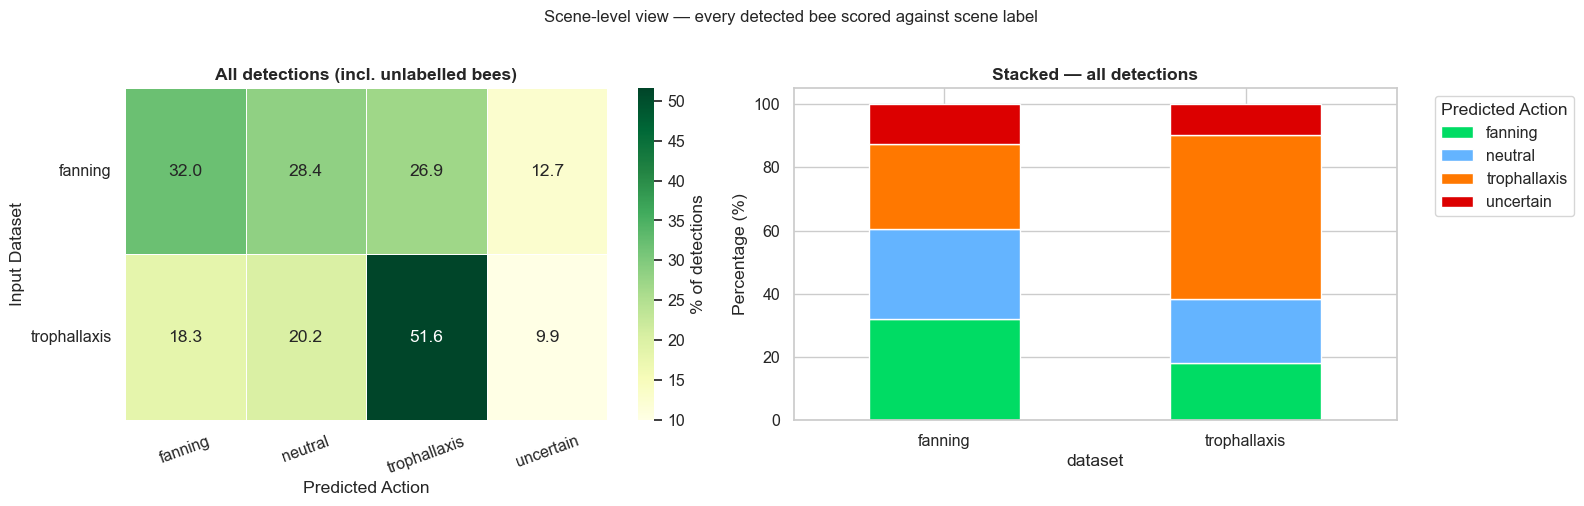

In [11]:
ar_df          = df[df['dataset'].isin(['fanning', 'trophallaxis'])].copy()
classified_all = ar_df[ar_df['action'] != 'buffering']
pivot_all      = classified_all.groupby(['dataset', 'action']).size().unstack(fill_value=0)
pivot_pct_all  = pivot_all.div(pivot_all.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.heatmap(pivot_pct_all, annot=True, fmt='.1f', cmap='YlGn', ax=axes[0],
            cbar_kws={'label': '% of detections'}, linewidths=0.5, linecolor='white')
axes[0].set_title('All detections (incl. unlabelled bees)', fontweight='bold')
axes[0].set_xlabel('Predicted Action'); axes[0].set_ylabel('Input Dataset')
axes[0].tick_params(axis='x', rotation=20); axes[0].tick_params(axis='y', rotation=0)
bar_c = [ACTION_COLORS_HEX.get(c, '#888') for c in pivot_pct_all.columns]
pivot_pct_all.plot(kind='bar', stacked=True, ax=axes[1], color=bar_c, edgecolor='white')
axes[1].set_title('Stacked — all detections', fontweight='bold')
axes[1].set_ylabel('Percentage (%)'); axes[1].set_ylim(0, 105)
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Predicted Action', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.suptitle('Scene-level view — every detected bee scored against scene label', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'graph_1a_all_detections.png'), dpi=150, bbox_inches='tight')
plt.show()

### Figure 1b — IoU-Matched Confusion (fair metric — only GT-annotated bees)

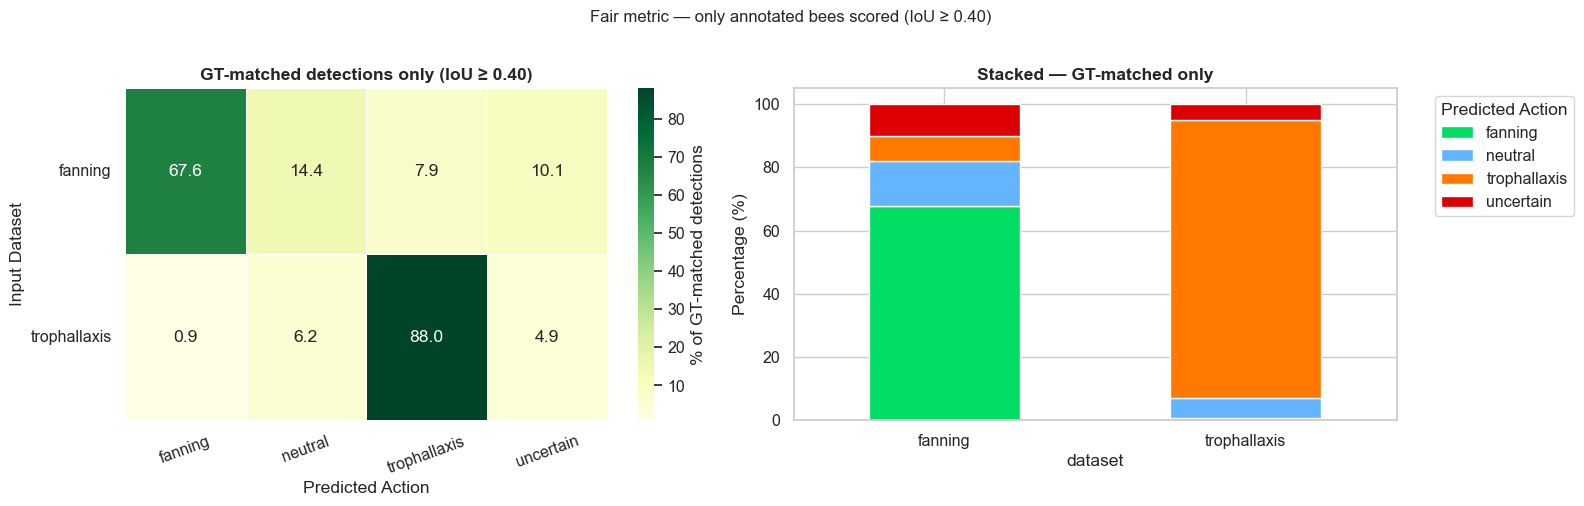

In [12]:
labeled_df    = ar_df[ar_df['is_labeled'] & (ar_df['action'] != 'buffering')]
pivot_lbl     = labeled_df.groupby(['dataset', 'action']).size().unstack(fill_value=0)
pivot_pct_lbl = pivot_lbl.div(pivot_lbl.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.heatmap(pivot_pct_lbl, annot=True, fmt='.1f', cmap='YlGn', ax=axes[0],
            cbar_kws={'label': '% of GT-matched detections'}, linewidths=0.5, linecolor='white')
axes[0].set_title('GT-matched detections only (IoU ≥ 0.40)', fontweight='bold')
axes[0].set_xlabel('Predicted Action'); axes[0].set_ylabel('Input Dataset')
axes[0].tick_params(axis='x', rotation=20); axes[0].tick_params(axis='y', rotation=0)
bar_c = [ACTION_COLORS_HEX.get(c, '#888') for c in pivot_pct_lbl.columns]
pivot_pct_lbl.plot(kind='bar', stacked=True, ax=axes[1], color=bar_c, edgecolor='white')
axes[1].set_title('Stacked — GT-matched only', fontweight='bold')
axes[1].set_ylabel('Percentage (%)'); axes[1].set_ylim(0, 105)
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Predicted Action', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.suptitle('Fair metric — only annotated bees scored (IoU ≥ 0.40)', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'graph_1b_iou_matched.png'), dpi=150, bbox_inches='tight')
plt.show()

### Figure 2 — Detection Confidence


Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



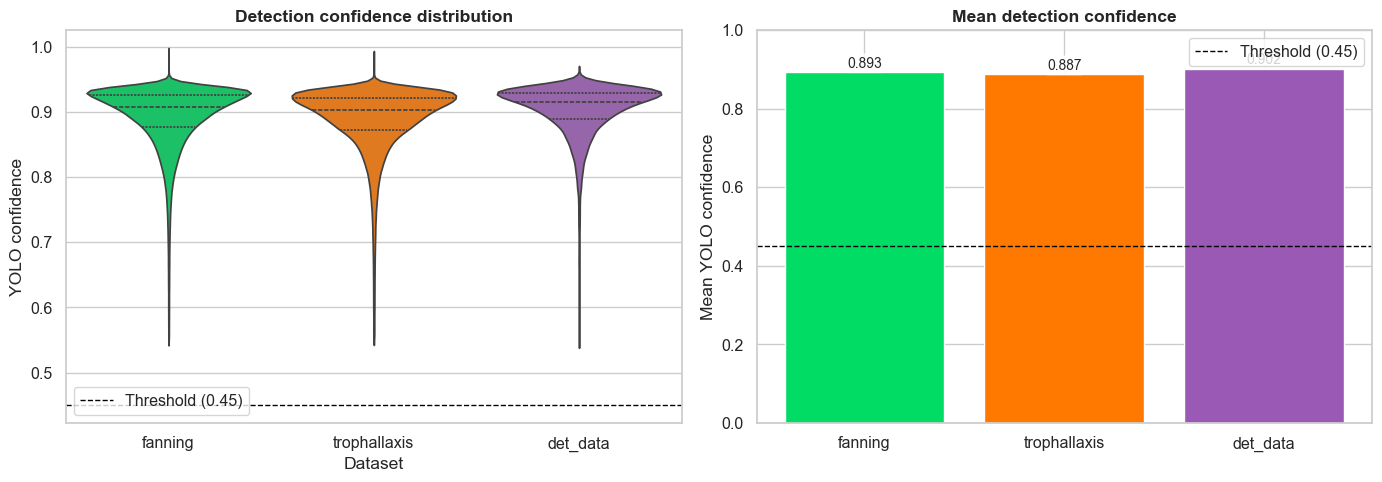

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.violinplot(data=df, x='dataset', y='det_conf', order=order,
               palette={d: DATASET_COLORS[d] for d in order}, inner='quartile', ax=axes[0])
axes[0].axhline(DET_CONF, color='black', linestyle='--', linewidth=1, label=f'Threshold ({DET_CONF})')
axes[0].set_title('Detection confidence distribution', fontweight='bold')
axes[0].set_xlabel('Dataset'); axes[0].set_ylabel('YOLO confidence'); axes[0].legend()

mean_conf = df.groupby('dataset')['det_conf'].mean().reindex(order)
bars = axes[1].bar(mean_conf.index, mean_conf.values,
                   color=[DATASET_COLORS[d] for d in mean_conf.index], edgecolor='white')
axes[1].axhline(DET_CONF, color='black', linestyle='--', linewidth=1, label=f'Threshold ({DET_CONF})')
for bar, val in zip(bars, mean_conf.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, val+0.005, f'{val:.3f}',
                 ha='center', va='bottom', fontsize=10,
                 bbox=dict(boxstyle='round,pad=0.15', facecolor='white', alpha=0.9))
axes[1].set_title('Mean detection confidence', fontweight='bold')
axes[1].set_ylabel('Mean YOLO confidence'); axes[1].set_ylim(0, 1.0); axes[1].legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'graph_2_det_confidence.png'), dpi=150, bbox_inches='tight')
plt.show()

### Figure 3 — Action Confidence: Correct vs Off-Target (GT-matched bees only)

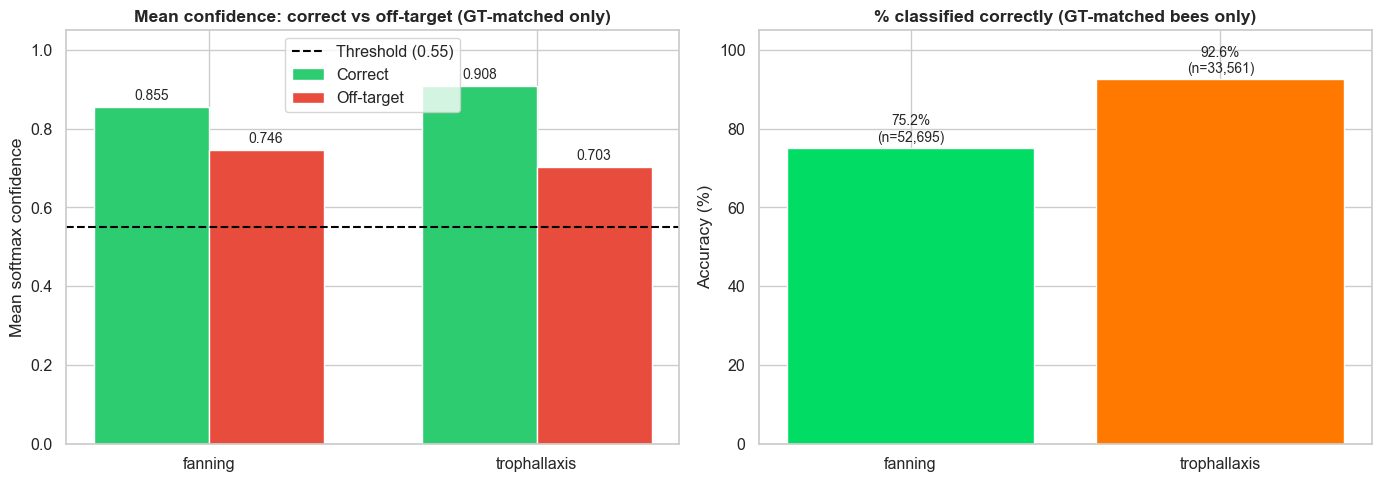

In [14]:
ar_cls = labeled_df[labeled_df['action'].isin(ACTION_CLASSES)].copy()
ar_cls['correct'] = ar_cls.apply(lambda r: r['action'] == r['dataset'], axis=1)
ds_labels = [d for d in ['fanning', 'trophallaxis'] if d in ar_cls['dataset'].unique()]
mean_ok, mean_bad = [], []
for ds in ds_labels:
    sub = ar_cls[ar_cls['dataset'] == ds]
    mean_ok.append(sub[sub['correct']]['action_conf'].mean())
    mean_bad.append(sub[~sub['correct']]['action_conf'].mean())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x, width = np.arange(len(ds_labels)), 0.35
b1 = axes[0].bar(x-width/2, mean_ok,  width, color='#2ecc71', edgecolor='white', label='Correct')
b2 = axes[0].bar(x+width/2, mean_bad, width, color='#e74c3c', edgecolor='white', label='Off-target')
for bar, val in zip(list(b1)+list(b2), mean_ok+mean_bad):
    if not np.isnan(val):
        axes[0].text(bar.get_x()+bar.get_width()/2, val+0.01, f'{val:.3f}',
                     ha='center', va='bottom', fontsize=10)
axes[0].axhline(ACTION_CONF_TH, color='black', linestyle='--', label=f'Threshold ({ACTION_CONF_TH})')
axes[0].set_xticks(x); axes[0].set_xticklabels(ds_labels); axes[0].set_ylim(0, 1.05)
axes[0].set_title('Mean confidence: correct vs off-target (GT-matched only)', fontweight='bold')
axes[0].set_ylabel('Mean softmax confidence'); axes[0].legend()

acc_rows = []
for ds in ds_labels:
    sub = ar_cls[ar_cls['dataset'] == ds]
    if len(sub):
        acc_rows.append({'dataset': ds, 'pct': sub['correct'].mean()*100, 'n': len(sub)})
acc_df = pd.DataFrame(acc_rows)
bars = axes[1].bar(acc_df['dataset'], acc_df['pct'],
                   color=[DATASET_COLORS.get(d, '#888') for d in acc_df['dataset']], edgecolor='white')
for bar, row in zip(bars, acc_df.itertuples()):
    axes[1].text(bar.get_x()+bar.get_width()/2, row.pct+0.8,
                 f'{row.pct:.1f}%\n(n={row.n:,})', ha='center', va='bottom', fontsize=10)
axes[1].set_ylim(0, 105)
axes[1].set_title('% classified correctly (GT-matched bees only)', fontweight='bold')
axes[1].set_ylabel('Accuracy (%)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'graph_3_action_confidence.png'), dpi=150, bbox_inches='tight')
plt.show()

### Figure 4 — Track Lifetime Distribution

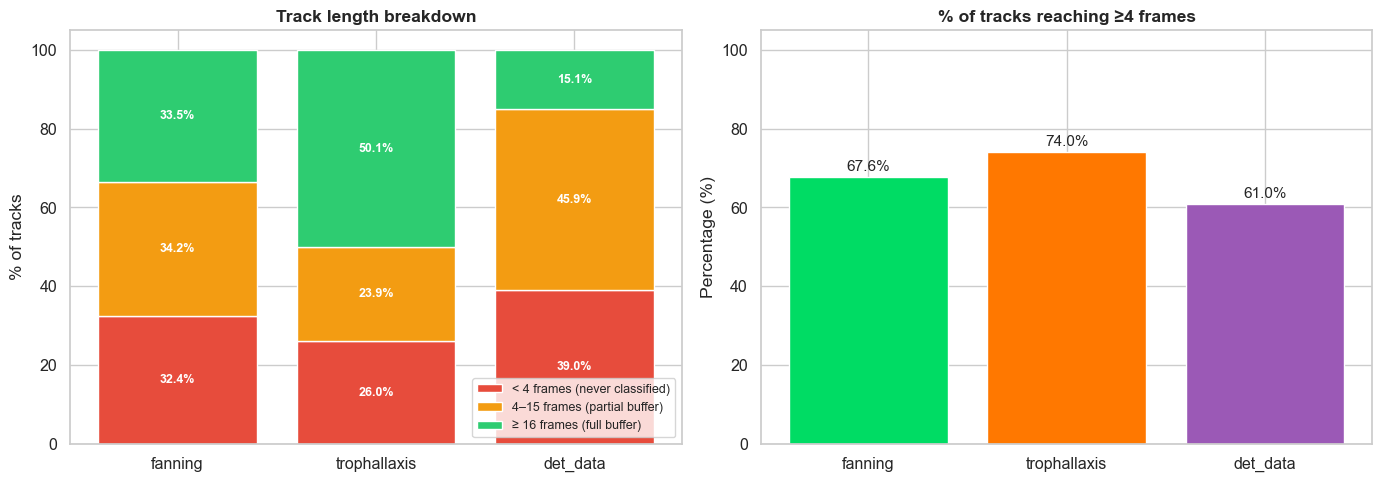

In [15]:
track_lengths = (
    df.groupby(['dataset', 'track_id'])['frame_idx'].count()
    .reset_index().rename(columns={'frame_idx': 'track_length'})
)
cat_labels  = [f'< {MIN_BUFFER} frames (never classified)',
               f'{MIN_BUFFER}–{BUFFER_SIZE-1} frames (partial buffer)',
               f'≥ {BUFFER_SIZE} frames (full buffer)']
cat_colors  = ['#e74c3c', '#f39c12', '#2ecc71']
cat_filters = [lambda s: s < MIN_BUFFER,
               lambda s: (s >= MIN_BUFFER) & (s < BUFFER_SIZE),
               lambda s: s >= BUFFER_SIZE]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x_pos  = np.arange(len(order))
bottom = np.zeros(len(order))
for lbl, color, fn in zip(cat_labels, cat_colors, cat_filters):
    vals = np.array([
        fn(track_lengths[track_lengths['dataset']==ds]['track_length']).sum() /
        max(len(track_lengths[track_lengths['dataset']==ds]), 1) * 100
        for ds in order
    ])
    b = axes[0].bar(x_pos, vals, bottom=bottom, color=color, edgecolor='white', label=lbl)
    for bar, v, bot in zip(b, vals, bottom):
        if v > 4:
            axes[0].text(bar.get_x()+bar.get_width()/2, bot+v/2, f'{v:.1f}%',
                         ha='center', va='center', fontsize=9, color='white', fontweight='bold')
    bottom += vals
axes[0].set_xticks(x_pos); axes[0].set_xticklabels(order)
axes[0].set_ylim(0, 105); axes[0].set_title('Track length breakdown', fontweight='bold')
axes[0].set_ylabel('% of tracks'); axes[0].legend(loc='lower right', fontsize=9)

pct_rows = [{'dataset': ds,
             'pct': (track_lengths[track_lengths['dataset']==ds]['track_length'] >= MIN_BUFFER).mean()*100}
            for ds in order]
pct_df = pd.DataFrame(pct_rows)
bars = axes[1].bar(pct_df['dataset'], pct_df['pct'],
                   color=[DATASET_COLORS.get(d, '#888') for d in pct_df['dataset']], edgecolor='white')
for bar, row in zip(bars, pct_df.itertuples()):
    axes[1].text(bar.get_x()+bar.get_width()/2, row.pct+0.8,
                 f'{row.pct:.1f}%', ha='center', va='bottom', fontsize=11)
axes[1].set_ylim(0, 105)
axes[1].set_title(f'% of tracks reaching ≥{MIN_BUFFER} frames', fontweight='bold')
axes[1].set_ylabel('Percentage (%)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'graph_4_track_lifetime.png'), dpi=150, bbox_inches='tight')
plt.show()

### Figure 5 — Majority-Vote Accuracy
Does the modal predicted class match the scene label? Per-track and scene-level.

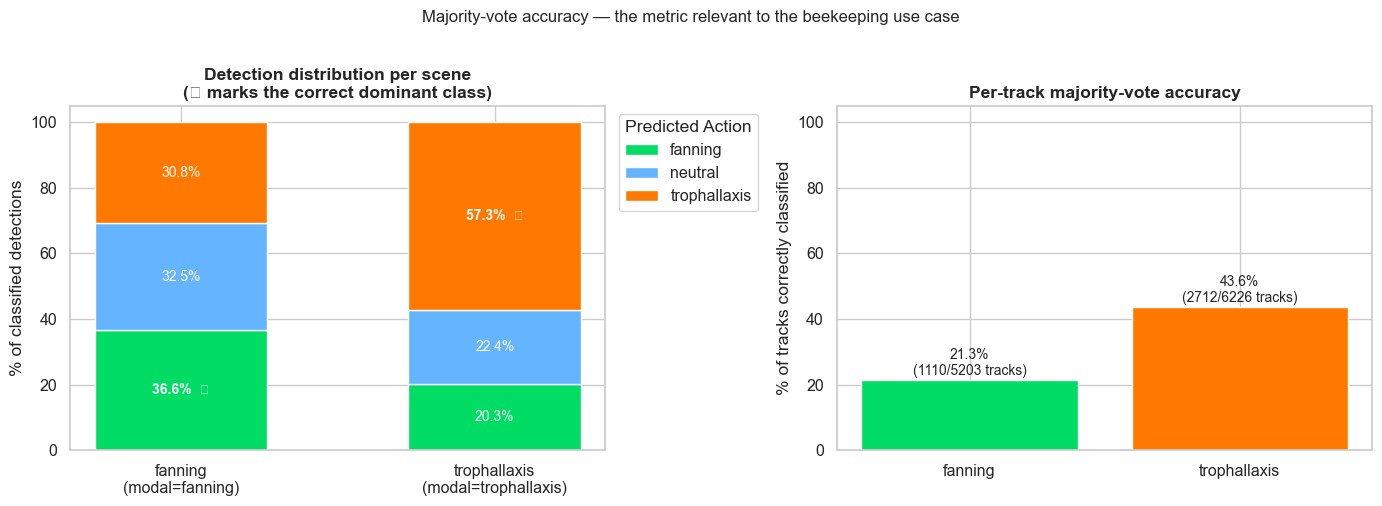

In [16]:
mv_rows = []
for ds in ['fanning', 'trophallaxis']:
    sub = df[(df['dataset']==ds) & df['action'].isin(ACTION_CLASSES)]
    if len(sub) == 0:
        continue
    track_votes    = sub.groupby('track_id')['action'].agg(lambda x: x.mode()[0])
    correct_tracks = (track_votes == ds).sum()
    scene_modal    = sub['action'].mode()[0]
    mv_rows.append({
        'dataset':        ds,
        'scene_modal':    scene_modal,
        'scene_correct':  scene_modal == ds,
        'track_accuracy': correct_tracks / len(track_votes) * 100,
        'correct_tracks': correct_tracks,
        'total_tracks':   len(track_votes),
        'pct_fanning':    (sub['action']=='fanning').mean()*100,
        'pct_neutral':    (sub['action']=='neutral').mean()*100,
        'pct_trophallaxis': (sub['action']=='trophallaxis').mean()*100,
    })
mv_df = pd.DataFrame(mv_rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: actual detection distribution per scene (stacked), correct class highlighted
ds_list = mv_df['dataset'].tolist()
x = np.arange(len(ds_list))
width = 0.55

bottom = np.zeros(len(ds_list))
for cls in ['fanning', 'neutral', 'trophallaxis']:
    vals = mv_df[f'pct_{cls}'].values
    bars = axes[0].bar(x, vals, width, bottom=bottom,
                       color=ACTION_COLORS_HEX[cls], edgecolor='white', label=cls)
    for bar, v, bot, ds in zip(bars, vals, bottom, ds_list):
        if v > 3:
            is_correct = (cls == ds)
            axes[0].text(bar.get_x()+bar.get_width()/2, bot+v/2,
                         f'{v:.1f}%{"  ✓" if is_correct else ""}',
                         ha='center', va='center', fontsize=10,
                         color='white', fontweight='bold' if is_correct else 'normal')
    bottom += vals

axes[0].set_xticks(x)
axes[0].set_xticklabels([f'{r.dataset}\n(modal={r.scene_modal})' for r in mv_df.itertuples()])
axes[0].set_ylim(0, 105)
axes[0].set_title('Detection distribution per scene\n(✓ marks the correct dominant class)', fontweight='bold')
axes[0].set_ylabel('% of classified detections')
axes[0].legend(title='Predicted Action', bbox_to_anchor=(1.01, 1), loc='upper left')

# Right: per-track majority-vote accuracy
bars = axes[1].bar(mv_df['dataset'], mv_df['track_accuracy'],
                   color=[DATASET_COLORS.get(d, '#888') for d in mv_df['dataset']], edgecolor='white')
for bar, row in zip(bars, mv_df.itertuples()):
    axes[1].text(bar.get_x()+bar.get_width()/2, row.track_accuracy+0.8,
                 f'{row.track_accuracy:.1f}%\n({row.correct_tracks}/{row.total_tracks} tracks)',
                 ha='center', va='bottom', fontsize=10)
axes[1].set_ylim(0, 105)
axes[1].set_title('Per-track majority-vote accuracy', fontweight='bold')
axes[1].set_ylabel('% of tracks correctly classified')

plt.suptitle('Majority-vote accuracy — the metric relevant to the beekeeping use case', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'graph_5_majority_vote.png'), dpi=150, bbox_inches='tight')
plt.show()

### Figure 6 — Temporal Smoothing Comparison

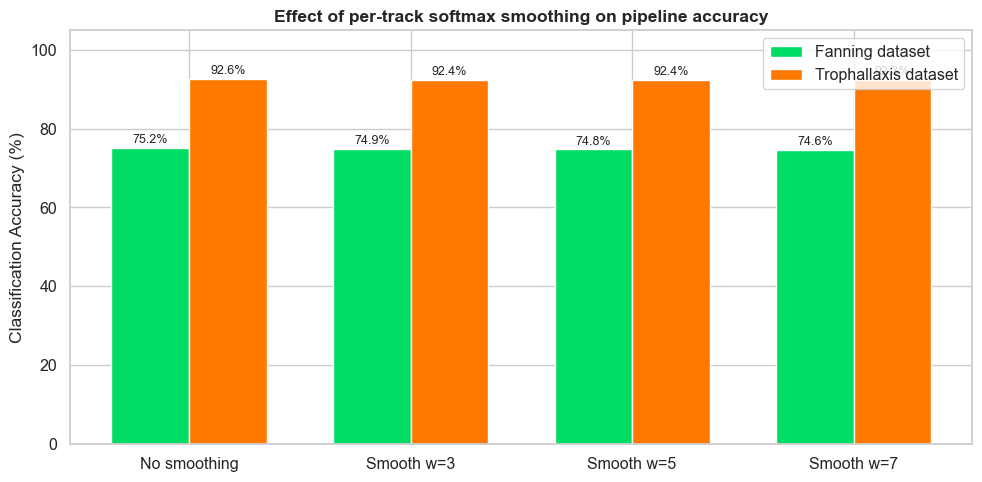

In [18]:
ar_df_s = labeled_df.copy()   # IoU-matched, non-buffering — includes uncertain rows for track context

def apply_smoothing(df_in, window):
    df_w = df_in.sort_values(['dataset', 'track_id', 'frame_idx'])
    label_map = {}
    for (ds, tid), grp in df_w.groupby(['dataset', 'track_id'], sort=False):
        probs_arr = grp[PROB_COLS].values
        for i, idx in enumerate(grp.index):
            if grp.loc[idx, 'action'] == 'buffering':
                label_map[idx] = 'buffering'; continue
            avg   = probs_arr[max(0, i-window+1):i+1].mean(axis=0)
            label = ACTION_CLASSES[int(avg.argmax())] if avg.max() >= ACTION_CONF_TH else 'uncertain'
            label_map[idx] = label
    return pd.Series(label_map)

strategies = {}
for ds in ['fanning', 'trophallaxis']:
    sub = ar_df_s[(ar_df_s['dataset']==ds) & (~ar_df_s['action'].isin(['buffering','uncertain']))]
    strategies.setdefault('No smoothing', {})[ds] = (sub['action']==ds).mean()*100
for w in [3, 5, 7]:
    col = f'smoothed_w{w}'
    ar_df_s[col] = apply_smoothing(ar_df_s, w)
    for ds in ['fanning', 'trophallaxis']:
        sub = ar_df_s[(ar_df_s['dataset']==ds) & (~ar_df_s[col].isin(['buffering','uncertain']))]
        strategies.setdefault(f'Smooth w={w}', {})[ds] = (sub[col]==ds).mean()*100

s_labels = list(strategies.keys())
x, width = np.arange(len(s_labels)), 0.35
fig, ax  = plt.subplots(figsize=(10, 5))
bars_f = ax.bar(x-width/2, [strategies[s]['fanning']      for s in s_labels],
                width, label='Fanning dataset',      color=DATASET_COLORS['fanning'],      edgecolor='white')
bars_t = ax.bar(x+width/2, [strategies[s]['trophallaxis'] for s in s_labels],
                width, label='Trophallaxis dataset', color=DATASET_COLORS['trophallaxis'], edgecolor='white')
for bar in [*bars_f, *bars_t]:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(s_labels)
ax.set_ylabel('Classification Accuracy (%)')
ax.set_title('Effect of per-track softmax smoothing on pipeline accuracy', fontweight='bold')
ax.legend(); ax.set_ylim(0, 105)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'graph_6_smoothing.png'), dpi=150, bbox_inches='tight')
plt.show()

### Summary

In [ ]:
print(f'Model      : {TEMPORAL_PATH}')
print(f'Epoch      : {ckpt["epoch"]}  Val F1: {ckpt["val_f1"]:.4f}')
print(f'Temperature: {temperature:.4f}')
print(f'\nIoU-matched accuracy (GT-annotated bees, IoU ≥ {IOU_THRESHOLD}):')
for ds in ['fanning', 'trophallaxis']:
    sub = labeled_df[(labeled_df['dataset']==ds) & labeled_df['action'].isin(ACTION_CLASSES)]
    if len(sub):
        acc = (sub['action']==ds).mean()*100
        print(f'  {ds:15s}: {acc:.1f}%  (n={len(sub):,})')
print(f'\nMajority-vote accuracy:')
for _, row in mv_df.iterrows():
    print(f'  {row["dataset"]:15s}: scene={chr(10003) if row["scene_correct"] else chr(10007)}  '
          f'per-track={row["track_accuracy"]:.1f}%')
print(f'\nGraphs saved to: {OUTPUT_DIR}')